In [1]:
import json

In [2]:
device="cuda:0"

In [3]:
import sys
sys.path.append("../../utils")
from torch_utils import *

In [4]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torchvision
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import Dataset
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor, Pad, Resize
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
from torchvision.io import decode_image
# Set random seed for reproducibility

In [5]:
"""# Root directory for dataset
dataroot = "data/celeba"

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 20

# Learning rate for optimizers
lr = 0.00001

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1"""

'# Root directory for dataset\ndataroot = "data/celeba"\n\n# Number of workers for dataloader\nworkers = 2\n\n# Batch size during training\nbatch_size = 128\n\n# Spatial size of training images. All images will be resized to this\n#   size using a transformer.\nimage_size = 64\n\n# Number of channels in the training images. For color images this is 3\nnc = 3\n\n# Size of z latent vector (i.e. size of generator input)\nnz = 100\n\n# Size of feature maps in generator\nngf = 64\n\n# Size of feature maps in discriminator\nndf = 64\n\n# Number of training epochs\nnum_epochs = 20\n\n# Learning rate for optimizers\nlr = 0.00001\n\n# Beta1 hyperparameter for Adam optimizers\nbeta1 = 0.5\n\n# Number of GPUs available. Use 0 for CPU mode.\nngpu = 1'

In [6]:
def square_pad(img):
    h, w = img.shape[1], img.shape[2]
    if h > w:
        return Pad((0, 0, h - w, 0))(img)
    else:
        return Pad((0, 0, 0, w - h))(img)
vit_transform_2 = torchvision.transforms.Compose([
    square_pad,
    Resize([128,128], interpolation=torchvision.transforms.InterpolationMode.BILINEAR),
    #normalize_mask,
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
def get_cat(img, root):
    for cat in os.listdir(root):
        if img+".jpg" in os.listdir(os.path.join(root, cat)):
            return cat

In [8]:
"""labels = []
root = ""
for line in test_csv[1:]:
    line = line.split(",")
    if line[7] == "0":
        continue
    x, y, w, h = [c.strip() for c in [line[2], line[3], line[4], line[5]]]
    x = x[2:]
    h = h[:-2]
    comp_name = "/".join(line[8].split("/")[-2:])
    cat = get_cat(line[1], os.path.join(root, "background"))
    labels.append(
        {
            "fg": line[0],
            "bg": line[1],
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "label": line[7],
            "comp_dir": os.path.join(root, "composite", comp_name),
            "fg_dir": os.path.join(root, "foreground", cat, line[0]+".jpg"),
            "bg_dir": os.path.join(root, "background", cat, line[1]+".jpg")

        }
    )
    """

'labels = []\nroot = ""\nfor line in test_csv[1:]:\n    line = line.split(",")\n    if line[7] == "0":\n        continue\n    x, y, w, h = [c.strip() for c in [line[2], line[3], line[4], line[5]]]\n    x = x[2:]\n    h = h[:-2]\n    comp_name = "/".join(line[8].split("/")[-2:])\n    cat = get_cat(line[1], os.path.join(root, "background"))\n    labels.append(\n        {\n            "fg": line[0],\n            "bg": line[1],\n            "x": x,\n            "y": y,\n            "w": w,\n            "h": h,\n            "label": line[7],\n            "comp_dir": os.path.join(root, "composite", comp_name),\n            "fg_dir": os.path.join(root, "foreground", cat, line[0]+".jpg"),\n            "bg_dir": os.path.join(root, "background", cat, line[1]+".jpg")\n\n        }\n    )\n    '

In [9]:
class OPADataset_4(Dataset):
    def __init__(self, label_dir, root_dir, fg_transform=None, bg_transform=None, comp_transform=None):
        self.labels = []
        self.bg_transform = bg_transform
        self.fg_transform = fg_transform
        self.comp_transform = comp_transform
        with open(label_dir, "r") as f:
            label_csv = f.readlines()
        for line in label_csv[1:]:
            line = line.split(",")
            if line[7] == "0":
                continue
            x, y, w, h = [c.strip() for c in [line[2], line[3], line[4], line[5]]]
            x = x[2:]
            h = h[:-2]
            comp_name = "/".join(line[8].split("/")[-2:])
            cat = get_cat(line[0], os.path.join(root_dir, "foreground"))
            self.labels.append(
                {
                    "fg": line[0],
                    "bg": line[1],
                    "x": x,
                    "y": y,
                    "w": w,
                    "h": h,
                    "label": line[7],
                    "comp_dir": os.path.join(root_dir, "composite", comp_name),
                    "fg_dir": os.path.join(root_dir, "foreground", cat, line[0]+".jpg"),
                    "mask_dir": os.path.join(root_dir, "foreground", cat, "mask_"+line[0]+".jpg"),
                    "bg_dir": os.path.join(root_dir, "background", cat, line[1]+".jpg")
                }
            )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label = self.labels[idx]
        fg_dir, bg_dir, comp_dir = label["fg_dir"], label["bg_dir"], label["comp_dir"]
        fg_image = decode_image(fg_dir).type(torch.float32)
        bg_image = decode_image(bg_dir).type(torch.float32)
        comp_image = decode_image(comp_dir).type(torch.float32)
        if self.fg_transform:
            fg_image = self.fg_transform(fg_image)
        if self.bg_transform:
            bg_image = self.bg_transform(bg_image)
        if self.comp_transform:
            comp_image = self.comp_transform(comp_image)
        return fg_image, bg_image, comp_image, label["label"], label

In [10]:
class CompositeDiscriminator(nn.Module):
    def __init__(self, in_channels=3, base_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, base_dim, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_dim, base_dim*2, 4, 2, 1),
            nn.BatchNorm2d(base_dim*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_dim*2, base_dim*4, 4, 2, 1),
            nn.BatchNorm2d(base_dim*4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_dim*4, 1, 4, 1, 0),
            nn.Flatten(),
            nn.Linear(169,84),
            nn.ReLU(inplace=True),
            nn.Linear(84, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def create_comp(labels, pred, outpath="output/", img_size=128):
    for i in range(len(pred)):
        label = "pred"
        fg_name = labels["fg_dir"][i]
        bg_name = labels["bg_dir"][i]
        mask_name = labels["mask_dir"][i]
        fg_id = labels["fg"][i]
        bg_id = labels["bg"][i]

        fg_img = Image.open(fg_name).convert('RGB')
        mask_img = Image.open(mask_name).convert('L')
        bg_img = Image.open(bg_name).convert('RGB')

        bg_h = bg_img.height
        bg_w = bg_img.width

        left,top,w,h = pred[i]
        left,top,w,h = [int(c.item() * img_size) for c in [left,top,w,h]]
        print(left,top,w,h)
        print(any([x < 0 for x in [left,top,w,h]]))

        right = w + left
        bottom = h + top

        com_pic_name = fg_id + "_" + bg_id + "_" + str(left) + "_" + str(top) + "_" + str(w) + "_" + str(
        h) + "_" + label + ".jpg"
        save_path = os.path.join(outpath, com_pic_name)

        if right - left <= 0 or bottom - top <= 0 or right > bg_w or bottom > bg_h or any([x < 0 for x in [left,top,w,h]]):
            img = transforms.ToPILImage()(torch.zeros(3, bg_h, bg_w)).convert('RGB')
            img.save(save_path)
            continue

        else:
            scale = max(w / bg_w, h / bg_h)
            str_scale = "%.9f" % scale
        
        fg_transform = transforms.Compose([
            transforms.Resize((bottom - top, right - left)),
            transforms.ToTensor(),
        ])
        fg_img_ = fg_transform(fg_img)
        mask_img_ = fg_transform(mask_img)
        fg_img = torch.zeros(3, bg_h, bg_w)
        mask_img = torch.zeros(3, bg_h, bg_w)
        fg_img[:, top:bottom, left:right] = fg_img_[:, :, :]
        mask_img[:, top:bottom, left:right] = mask_img_[:, :, :]
        bg_img = transforms.ToTensor()(bg_img)
        blended = fg_img * mask_img + bg_img * (1 - mask_img)
        com_pic = transforms.ToPILImage()(blended).convert('RGB')
        
        label = 'predicted'

        com_pic.save(save_path)



In [12]:
from PIL import Image

In [13]:
class OPAImageFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.samples = os.listdir(root_dir)
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.samples[idx])
        image = decode_image(img_path).type(torch.float32)
        if self.transform:
            image = self.transform(image)
        return image

In [14]:
torch.cuda.empty_cache()

In [15]:
ds = OPADataset_4("test_set.csv","",vit_transform_2,vit_transform_2,vit_transform_2)
dataloader = DataLoader(ds,batch_size=16)
netD = CompositeDiscriminator()
netG = fusion_v5()
device = "cuda:0"
netD.to(device)
netG.to(device)

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [19]:
any(x < 0 for x in [-12 -12 -45 -69])

True

In [21]:
# 1. Update Generator on Real Img
# 2. Generate Fake Img
# 3. Update Generator on Fake Img
# 4. Update Generator from Adv. Loss
criterion = nn.BCELoss()
img_list = []
G_losses = []
D_losses = []
iters = 0
num_epochs = 20

# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        fg_image, bg_image, comp_image, _, label = data

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_batch = comp_image.to(device)
        b_size = real_batch.size(0)
        real_label = torch.full((b_size,), 1, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_batch).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, real_label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate fake image batch with G
        fg_image, bg_image = fg_image.to(device), bg_image.to(device)
        generator_input = torch.cat((bg_image,fg_image),1)
        fake_pos = netG(generator_input)
        fake_label = torch.full((b_size,), 0, dtype=torch.float, device=device)

        ## Generate composite images from the position predicted by generator
        create_comp(label, fake_pos, outpath="temp/")
        fake_ds = OPAImageFolder(root_dir="output", transform=vit_transform_2)
        fake_img = next(iter( DataLoader(fake_ds,batch_size=b_size) ))

        # Classify all fake batch with D
        output = netD(fake_img).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, fake_label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        # label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake_img).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, real_label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        folder_path = "/path/to/folder"

        for filename in os.listdir("output"):
            file_path = os.path.join("output", filename)
            if os.path.isfile(file_path):
                os.remove(file_path)

        iters += 1

17 22 -13 -76
True


ValueError: height and width must be > 0

In [ ]:
class OneHotImageFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # Sort for deterministic class indices
        self.classes = sorted(
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        )

        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.num_classes = len(self.classes)

        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')) and not fname.startswith("mask"):
                    self.samples.append(
                        (os.path.join(cls_dir, fname), self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, class_idx = self.samples[idx]
        image = decode_image(img_path).type(torch.float32)
        if self.transform:
            image = self.transform(image)

        # one-hot label
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        label[class_idx] = 1.0

        return image

In [8]:
transform=torchvision.transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [9]:
dataset = OneHotImageFolder("foreground",transform=transform)

In [39]:
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True)

In [31]:
real_batch.shape

torch.Size([128, 3, 64, 64])

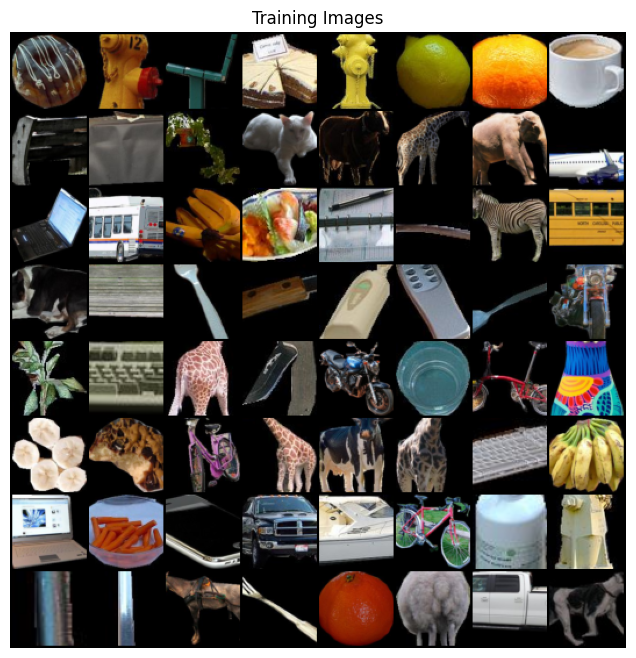

In [42]:
# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch.to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [12]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [13]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. ``(ngf*8) x 4 x 4``
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. ``(ngf*4) x 8 x 8``
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. ``(ngf*2) x 16 x 16``
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. ``(ngf) x 32 x 32``
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. ``(nc) x 64 x 64``
        )

    def forward(self, input):
        return self.main(input)

In [51]:
# Create the generator
netG = Generator(ngpu).to("cuda:0")

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [15]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is ``(nc) x 64 x 64``
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf) x 32 x 32``
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*2) x 16 x 16``
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*4) x 8 x 8``
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*8) x 4 x 4``
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [50]:
# Create the Discriminator
netD = Discriminator(ngpu).to("cuda:0")

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [17]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [65]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/20][0/33]	Loss_D: 1.6093	Loss_G: 0.6534	D(x): 0.6186	D(G(z)): 0.5779 / 0.5779
[1/20][0/33]	Loss_D: 1.6113	Loss_G: 0.6400	D(x): 0.6101	D(G(z)): 0.5834 / 0.5834
[2/20][0/33]	Loss_D: 1.5319	Loss_G: 0.6113	D(x): 0.6533	D(G(z)): 0.5864 / 0.5864
[3/20][0/33]	Loss_D: 1.6324	Loss_G: 0.6591	D(x): 0.6189	D(G(z)): 0.5802 / 0.5802
[4/20][0/33]	Loss_D: 1.6074	Loss_G: 0.6256	D(x): 0.6347	D(G(z)): 0.5890 / 0.5890
[5/20][0/33]	Loss_D: 1.5755	Loss_G: 0.6868	D(x): 0.6240	D(G(z)): 0.5649 / 0.5649
[6/20][0/33]	Loss_D: 1.5053	Loss_G: 0.6525	D(x): 0.6275	D(G(z)): 0.5673 / 0.5673
[7/20][0/33]	Loss_D: 1.5800	Loss_G: 0.6686	D(x): 0.6271	D(G(z)): 0.5695 / 0.5695
[8/20][0/33]	Loss_D: 1.4238	Loss_G: 0.7393	D(x): 0.6453	D(G(z)): 0.5394 / 0.5394
[9/20][0/33]	Loss_D: 1.6531	Loss_G: 0.6131	D(x): 0.6047	D(G(z)): 0.5871 / 0.5871
[10/20][0/33]	Loss_D: 1.6019	Loss_G: 0.6489	D(x): 0.6260	D(G(z)): 0.5850 / 0.5850
[11/20][0/33]	Loss_D: 1.5092	Loss_G: 0.6543	D(x): 0.6543	D(G(z)): 0.5686 / 0.5686


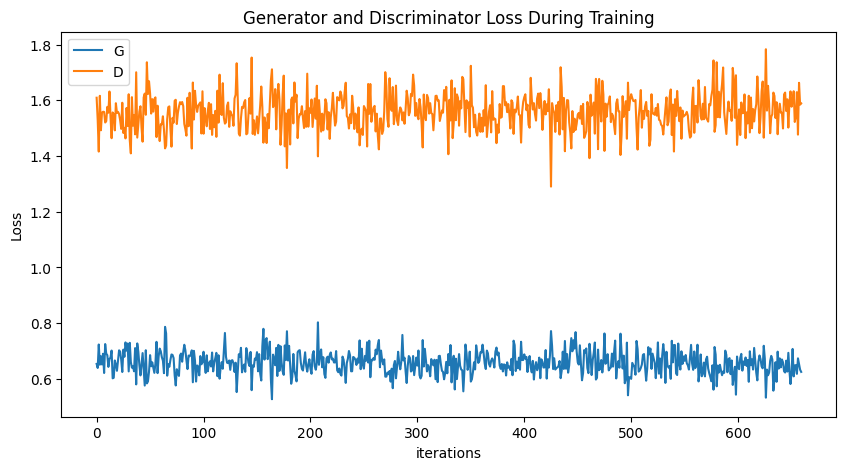

In [66]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()


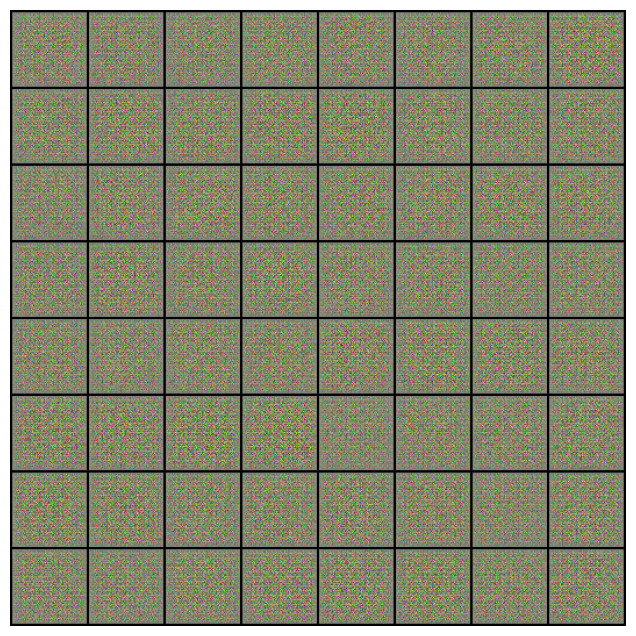

In [67]:
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

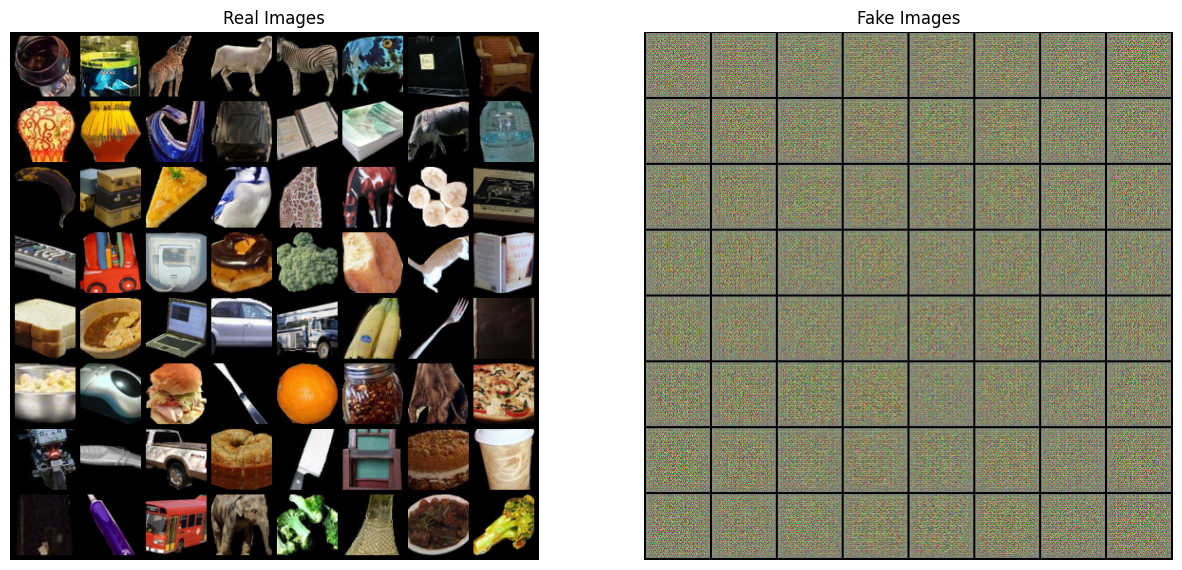

In [64]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch.to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()